# Leaf Image Processing

Pipeline desta etapa: **denoising → Sobel e Canny → GLCM**.

Uma fotografia por classe. Após a comparação de denoising, aplicamos os métodos
de bordas à imagem escolhida. Só depois apresentamos uma aplicação de GLCM.
O desenvolvimento para aqui: sem FFT, LBP, segmentação ou testes adicionais.


## Preparação técnica

Os quatro filtros foram comparados por busca em grades de parâmetros no Experimento 1.
Usamos os **melhores parâmetros encontrados nas grades avaliadas**, sem repetir a busca aqui.

Esta versão contém uma fotografia dos resultados salvos em
`local/denoising_output/experimento1_compacto_40_bm3d3/best_params_tuning.json` (arquivo historico local),
lidos em **21/09/2026, 16:39 UTC**. Sigma 5 e 10 estão completos; sigma 15 está parcial.
Os resultados de tuning não são uma avaliação final de generalização.

O filtro Gaussiano é uma comparação adicional: seus parâmetros são manuais e ele não
participou da busca. Nas células abaixo estão todas as configurações, funções e cálculos.
Execute com o kernel **Python (Leaf Image Processing)**. O snapshot abaixo e as quatro amostras acompanham o repositorio.

A busca antiga é mantida como histórico, não repetida. NLM/BM3D são opcionais.
Todas as funções estão neste notebook, organizadas no início por responsabilidade:
filtros, bordas, GLCM e apresentação. Cada filtro tem sua própria função.
Não há módulos locais adicionais a importar nem dependência do ImageJ.


In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage.feature import graycomatrix, graycoprops
from IPython.display import display, Markdown

# Configuracao da apresentacao.
SIGMA_PARAMETROS = 10
FILTRO_VISUAL = None  # Preencha depois: "median", "bilateral", "nlm", "bm3d" ou "gaussian".
JUSTIFICATIVA_VISUAL = ""
FILTRO_FINAL = None  # None usa provisoriamente o vencedor numerico.
JUSTIFICATIVA_FINAL = ""

# A demonstracao aplica os filtros diretamente nas imagens originais.
# sigma do experimento (intensidade 0..255) != sigma espacial do filtro Gaussiano.
PARAMETROS_GAUSSIANO = {"kernel": 5, "sigma": 1.0}

PASTA_PROJETO = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "notebooks" / "apple_leaf_analysis.ipynb").is_file()),
    None,
)
if PASTA_PROJETO is None:
    raise FileNotFoundError("Execute a partir da raiz do projeto ou da pasta notebooks/.")

PASTA_IMAGENS = PASTA_PROJETO / "data" / "samples"
FONTE_RESULTADOS = "local/denoising_output/experimento1_compacto_40_bm3d3/best_params_tuning.json"
PASTA_SAIDAS = PASTA_PROJETO / "outputs"
DATA_SNAPSHOT = "2026-09-21 16:39 UTC"
CLASSES = {
    "Apple___healthy": "Maçã saudável",
    "Apple___Apple_scab": "Sarna da macieira",
    "Apple___Black_rot": "Podridão negra",
    "Apple___Cedar_apple_rust": "Ferrugem da macieira",
}
# Quarta imagem de cada classe na ordenacao do experimento: fora do tuning.
ARQUIVOS_AMOSTRA = {
    "Apple___healthy": "image (1000).JPG",
    "Apple___Apple_scab": "image (101).JPG",
    "Apple___Black_rot": "image (101).JPG",
    "Apple___Cedar_apple_rust": "image (101).JPG",
}
NOMES_FILTROS = {
    "median": "Mediana",
    "bilateral": "Bilateral",
    "nlm": "Non-Local Means",
    "bm3d": "BM3D",
    "gaussian": "Gaussiano",
}
METODOS_EXPERIMENTO = ("median", "bilateral", "nlm", "bm3d")

# Foco recomendado pelo professor; historicos opcionais.
MOSTRAR_HISTORICOS = False
METODOS_FOCO = ("bilateral", "gaussian", "median")
METODOS_APRESENTACAO = METODOS_FOCO + (("nlm", "bm3d") if MOSTRAR_HISTORICOS else ())

# ROIs exploratorias (x, y, largura, altura), iguais entre filtros.
# Conferir os retangulos antes de interpretar os descritores.
ROIS = {
    "Apple___healthy": (100, 65, 64, 64),
    "Apple___Apple_scab": (105, 60, 64, 64),
    "Apple___Black_rot": (100, 100, 64, 64),
    "Apple___Cedar_apple_rust": (100, 85, 64, 64),
}
NIVEIS_GLCM = 32
DISTANCIAS_GLCM = (1, 2, 4)
ANGULOS_GLCM = (0, np.pi / 4, np.pi / 2, 3 * np.pi / 4)
# Configuracao do Canny; Sobel exibe a magnitude, sem binarizacao adicional.
LIMIARES_CANNY = (50.0, 100.0)


In [2]:
# Resultados congelados: nao consulta nem modifica o experimento em andamento.
RESULTADOS_EXPERIMENTO = {
    "5": {
        "median": {
            "params": {
                "kernel": 3
            },
            "metrics": {
                "mse": 145.62908172607422,
                "psnr": 29.015746691694503,
                "ssim": 0.7108893684753909
            },
            "search_time_seconds": 6.257430794008542,
            "signature": "1a225efce9146ff9090ade9a74998b4c9739b974f33c2ec2bd0c4cfa9c6e8223",
            "num_candidates": 5,
            "num_tuning_samples": 36
        },
        "bilateral": {
            "params": {
                "diameter": 11,
                "sigma_color": 15,
                "sigma_space": 5
            },
            "metrics": {
                "mse": 10.814486468279803,
                "psnr": 37.84144902326625,
                "ssim": 0.9531789619777606
            },
            "search_time_seconds": 456.2859037929011,
            "signature": "6057240eeb227ccaa123d712d28053df2e6cbced0b06abdb6a5a21ea478755da",
            "num_candidates": 500,
            "num_tuning_samples": 36
        },
        "nlm": {
            "params": {
                "h": 2,
                "h_color": 2.5,
                "template_window": 7,
                "search_window": 21
            },
            "metrics": {
                "mse": 16.02357030797888,
                "psnr": 36.16426383872067,
                "ssim": 0.9384547720440496
            },
            "search_time_seconds": 200.88340962701477,
            "signature": "5d6e9f7f7b381665aadf646a78ef623b9010f3525dedcfa42d0b20e16041633c",
            "num_candidates": 40,
            "num_tuning_samples": 36
        },
        "bm3d": {
            "params": {
                "sigma_factor": 1,
                "sigma_psd": 0.0196078431372549,
                "profile": "np",
                "stage": "ALL_STAGES"
            },
            "metrics": {
                "mse": 14.45155617042824,
                "psnr": 36.82070636723775,
                "ssim": 0.9477103899952252
            },
            "search_time_seconds": 328.45147896800336,
            "signature": "ff91343647b682fed044adc3ebd56a6544042449e317664c3aa1b70d54438136",
            "num_candidates": 3,
            "num_tuning_samples": 36
        }
    },
    "10": {
        "median": {
            "params": {
                "kernel": 3
            },
            "metrics": {
                "mse": 159.1414667765299,
                "psnr": 28.005936935776358,
                "ssim": 0.6581708157408964
            },
            "search_time_seconds": 3.891623960007564,
            "signature": "ee3c7aef102ba365e2615e10bc5be4841cc0ba2901e24f1febf44a98ac7c094e",
            "num_candidates": 5,
            "num_tuning_samples": 36
        },
        "bilateral": {
            "params": {
                "diameter": 11,
                "sigma_color": 30,
                "sigma_space": 5
            },
            "metrics": {
                "mse": 30.270472208658855,
                "psnr": 33.470537914729896,
                "ssim": 0.8809276585682988
            },
            "search_time_seconds": 403.029068967051,
            "signature": "6fe5702f15b2aadb3020ddc5b4ada497bc76a8f1f61033ffa54f48ad8d3ff124",
            "num_candidates": 500,
            "num_tuning_samples": 36
        },
        "nlm": {
            "params": {
                "h": 4,
                "h_color": 5,
                "template_window": 7,
                "search_window": 21
            },
            "metrics": {
                "mse": 42.6248313056098,
                "psnr": 32.08203998142299,
                "ssim": 0.8601418188208684
            },
            "search_time_seconds": 206.25895732900244,
            "signature": "819ed065a6fd7bbe1fcadd1aac0d35b150adf77ab20953c2082a8e0fc2289416",
            "num_candidates": 40,
            "num_tuning_samples": 36
        },
        "bm3d": {
            "params": {
                "sigma_factor": 1,
                "sigma_psd": 0.0392156862745098,
                "profile": "np",
                "stage": "ALL_STAGES"
            },
            "metrics": {
                "mse": 41.00092160260236,
                "psnr": 32.553789595803806,
                "ssim": 0.8604389570931061
            },
            "search_time_seconds": 334.8361483100016,
            "signature": "89f5f210c423a79aa0ddcf15d477ccf5f51e2aea958d4b9c44f3cc0abe0bf8e2",
            "num_candidates": 3,
            "num_tuning_samples": 36
        }
    },
    "15": {
        "median": {
            "params": {
                "kernel": 5
            },
            "metrics": {
                "mse": 188.54212315877282,
                "psnr": 26.994856309196038,
                "ssim": 0.5793776052173629
            },
            "search_time_seconds": 3.876872020002338,
            "signature": "e053b94f41eada37865edd9524b2c101e1a848be5e4bd69f58427e78a6413e44",
            "num_candidates": 5,
            "num_tuning_samples": 36
        },
        "bilateral": {
            "params": {
                "diameter": 11,
                "sigma_color": 50,
                "sigma_space": 5
            },
            "metrics": {
                "mse": 53.63194868299696,
                "psnr": 31.128840537135154,
                "ssim": 0.8095448902264134
            },
            "search_time_seconds": 400.19017765404715,
            "signature": "f199f2789d35578b2e41435780e2f287184f6cf193da6fc963c05946624979a4",
            "num_candidates": 500,
            "num_tuning_samples": 36
        }
    }
}


### Fórmulas e critérios

Para a imagem de referência \(I\) e a filtrada \(\hat I\), o experimento usa:

\[
MSE=\frac{1}{N}\sum_{i=1}^{N}(I_i-\hat I_i)^2,\qquad
PSNR=10\log_{10}\left(\frac{255^2}{MSE}\right).
\]

O PSNR médio no tuning determina a escolha numérica; SSIM é o desempate.
Menor MSE e maiores PSNR/SSIM são desejáveis. Não recalculamos essas métricas contra
as originais desta demonstração, pois não há referência limpa independente para seu ruído real.

O filtro Gaussiano usa pesos espaciais proporcionais a
\[
G(x,y)=\exp\left(-\frac{x^2+y^2}{2\sigma_g^2}\right),
\]
normalizados na janela \(5\times5\), com \(\sigma_g=1\) pixel.
Já o BM3D recebe o desvio-padrão de intensidade normalizado: \(\sigma_{\rm BM3D}=\sigma_{\rm ruído}/255\) quando o fator selecionado é 1.

A inspeção visual considera preservação de lesões, bordas e textura, alteração de cor
e suavização excessiva. A escolha visual só é registrada após avaliação humana.


### Bordas e GLCM: definições

Sobel calcula \(G_x,G_y\) e a magnitude \(\sqrt{G_x^2+G_y^2}\).
Canny produz bordas binárias com supressão de não máximos e histerese.
São métodos independentes sobre a mesma imagem denoised em cinza; não aplicamos Canny sobre Sobel.

Após exibir as bordas, aplicamos somente **GLCM**. A entrada da GLCM é o recorte
em cinza da imagem denoised, não uma máscara binária ou uma segmentação derivada das bordas.
As ROIs são apenas recortes exploratórios, mantidos explicitamente na configuração.

Quantização: \(q=\lfloor I\,L/256\rfloor\), \(L=32\).
\(P(i,j\mid d,\theta)\) conta pares de níveis em uma distância e direção, normalizados e simetrizados.
Extraímos contraste, dissimilaridade, homogeneidade, ASM, energia e correlação,
todos descritores do mesmo método GLCM, não seis métodos de textura diferentes.
A tabela completa mantém distâncias/direções; a média serve apenas como resumo.

Referência: [GLCM, scikit-image](https://scikit-image.org/docs/0.25.x/api/skimage.feature.html#skimage.feature.graycomatrix).


### Funções de processamento

Cada função recebe uma imagem e retorna seu resultado. Não desenha figuras nem salva arquivos.


In [3]:
def grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def median(image, kernel=3):
    return cv2.medianBlur(image, kernel)


def bilateral(image, diameter=11, sigma_color=30, sigma_space=5):
    return cv2.bilateralFilter(image, diameter, sigma_color, sigma_space)


def gaussian(image, kernel=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel, kernel), sigmaX=sigma, sigmaY=sigma)


def nlm(image, h, h_color, template_window=7, search_window=21):
    return cv2.fastNlMeansDenoisingColored(
        image, None, h=h, hColor=h_color,
        templateWindowSize=template_window, searchWindowSize=search_window)


def bm3d_filter(image, sigma_psd, profile="np", stage="ALL_STAGES", sigma_factor=1):
    """sigma_psd already includes the historical sigma_factor; do not apply it twice."""
    from bm3d import bm3d, BM3DStages
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255
    result = bm3d(rgb, sigma_psd=sigma_psd, profile=profile,
                  stage_arg=getattr(BM3DStages, stage))
    result = (np.clip(result, 0, 1) * 255 + .5).astype(np.uint8)
    return cv2.cvtColor(result, cv2.COLOR_RGB2BGR)


In [4]:
def sobel(image):
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
    return cv2.magnitude(gx, gy)


def canny(image, low=50, high=100):
    return cv2.Canny(image, low, high, apertureSize=3, L2gradient=True) > 0


In [5]:
def validate_gray(image):
    if image.ndim != 2 or image.dtype != np.uint8 or image.size == 0:
        raise ValueError("Expected a nonempty grayscale uint8 image.")


def crop_roi(image, box):
    """box = (x, y, width, height), with no resizing or background filling."""
    if len(box) != 4 or not all(isinstance(v, (int, np.integer)) for v in box):
        raise ValueError("ROI coordinates must be four integers.")
    x, y, width, height = box
    rows, cols = image.shape[:2]
    if min(x, y) < 0 or min(width, height) <= 0 or x + width > cols or y + height > rows:
        raise ValueError("ROI must lie entirely inside the image.")
    return image[y:y + height, x:x + width].copy()


def glcm(image, levels=32, distances=(1, 2, 4), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    validate_gray(image)
    if not isinstance(levels, int) or not 2 <= levels <= 256:
        raise ValueError("levels must be an integer in [2, 256].")
    if not distances or any(int(d) != d or d < 1 or d >= min(image.shape) for d in distances):
        raise ValueError("Distances must be positive integers smaller than the ROI.")
    if not angles or not np.isfinite(angles).all():
        raise ValueError("Provide finite angles.")
    quantized = (image.astype(np.uint16) * levels // 256).astype(np.uint8)
    return graycomatrix(quantized, distances, angles, levels=levels, symmetric=True, normed=True)


def glcm_properties(matrix):
    names = ("contrast", "dissimilarity", "homogeneity", "energy", "ASM", "correlation")
    return {name: graycoprops(matrix, name) for name in names}


In [6]:
def show_rois(images, boxes, names):
    fig, axes = plt.subplots(1, len(images), figsize=(16, 4), layout="constrained", squeeze=False)
    for ax, (label, image) in zip(axes[0], images.items()):
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        x, y, width, height = boxes[label]
        ax.add_patch(Rectangle((x, y), width, height, fill=False, edgecolor="yellow", linewidth=2))
        ax.set_title(names[label])
        ax.axis("off")
    plt.show()
    plt.close(fig)


In [7]:
def preparar_resultados():
    completos = [
        int(sigma) for sigma, methods in RESULTADOS_EXPERIMENTO.items()
        if all(method in methods for method in METODOS_EXPERIMENTO)
    ]
    if SIGMA_PARAMETROS not in completos:
        raise ValueError(f"Escolha um sigma completo: {sorted(completos)}.")
    registro = RESULTADOS_EXPERIMENTO[str(SIGMA_PARAMETROS)]
    parametros = {m: registro[m]["params"].copy() for m in METODOS_EXPERIMENTO}
    parametros["gaussian"] = PARAMETROS_GAUSSIANO.copy()
    vencedor = max(METODOS_EXPERIMENTO, key=lambda m: (
        registro[m]["metrics"]["psnr"], registro[m]["metrics"]["ssim"]))
    for selected in (FILTRO_VISUAL, FILTRO_FINAL):
        if selected is not None and selected not in NOMES_FILTROS:
            raise ValueError(f"Filtro desconhecido: {selected}")
    return parametros, vencedor


def carregar_amostras():
    imagens = {}
    for classe in CLASSES:
        caminho = PASTA_IMAGENS / classe / ARQUIVOS_AMOSTRA[classe]
        imagem = cv2.imread(str(caminho), cv2.IMREAD_COLOR)
        if imagem is None:
            raise FileNotFoundError(f"Nao foi possivel ler: {caminho}")
        imagens[classe] = imagem
    return imagens


def resultados_visuais(metodo):
    return RESULTADOS_FILTROS[metodo]


def desenhar_imagem(ax, imagem, titulo):
    ax.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB), interpolation="nearest")
    ax.set_title(titulo, fontsize=11)
    ax.axis("off")


def mostrar_linha(imagens, titulo):
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4.6), layout="constrained")
    for ax, classe in zip(axes, CLASSES):
        desenhar_imagem(ax, imagens[classe], CLASSES[classe])
    fig.suptitle(titulo, fontsize=16)
    plt.show()
    plt.close(fig)


def mostrar_originais():
    mostrar_linha(AMOSTRAS, "Referência visual — imagens originais")


def mostrar_filtro(metodo):
    mostrar_linha(resultados_visuais(metodo), NOMES_FILTROS[metodo])


def mostrar_resultados_experimento():
    status = []
    linhas = []
    for sigma, methods in sorted(RESULTADOS_EXPERIMENTO.items(), key=lambda item: int(item[0])):
        completo = all(m in methods for m in METODOS_EXPERIMENTO)
        status.append({"Sigma": int(sigma), "Filtros concluídos": len(methods),
                       "Situação": "Completo" if completo else "Parcial; fora da seleção"})
        if completo:
            for metodo in METODOS_EXPERIMENTO:
                data = methods[metodo]
                linhas.append({
                    "Sigma": int(sigma), "Filtro": NOMES_FILTROS[metodo],
                    "PSNR (dB)": data["metrics"]["psnr"], "SSIM": data["metrics"]["ssim"],
                    "MSE": data["metrics"]["mse"], "Candidatos": data["num_candidates"],
                    "Amostras de tuning": data["num_tuning_samples"],
                })
    display(pd.DataFrame(status).style.hide(axis="index"))
    tabela = pd.DataFrame(linhas).sort_values(["Sigma", "PSNR (dB)"], ascending=[True, False])
    display(tabela.style.hide(axis="index").format(
        {"PSNR (dB)": "{:.3f}", "SSIM": "{:.4f}", "MSE": "{:.3f}"}))
    display(Markdown(
        f"**Escolha numérica para sigma {SIGMA_PARAMETROS}: "
        f"{NOMES_FILTROS[FILTRO_NUMERICO]}.** "
        "Resultados médios de tuning; não são métricas das quatro fotos exibidas abaixo. "
        "Gaussiano não participou desta busca."))


def mostrar_parametros():
    linhas = []
    for metodo in METODOS_APRESENTACAO:
        p = PARAMETROS[metodo]
        descricao = ", ".join(f"{k}={v:.6g}" if isinstance(v, float) else f"{k}={v}"
                              for k, v in p.items())
        linhas.append({"Filtro": NOMES_FILTROS[metodo], "Parâmetros": descricao,
                       "Origem": "Manual; comparação adicional" if metodo == "gaussian"
                       else f"Melhor da grade no tuning; sigma {SIGMA_PARAMETROS}"})
    display(pd.DataFrame(linhas).style.hide(axis="index"))


def mostrar_amostras():
    display(pd.DataFrame([
        {"Classe": CLASSES[c], "Pasta": c, "Arquivo": ARQUIVOS_AMOSTRA[c]}
        for c in CLASSES
    ]).style.hide(axis="index"))
    mostrar_originais()


def mostrar_escolha():
    escolhido = FILTRO_FINAL or FILTRO_NUMERICO
    valores = RESULTADOS_EXPERIMENTO[str(SIGMA_PARAMETROS)][FILTRO_NUMERICO]["metrics"]
    resumo = (f"**Melhor pelas métricas:** {NOMES_FILTROS[FILTRO_NUMERICO]} "
              f"(sigma {SIGMA_PARAMETROS}, PSNR médio {valores['psnr']:.3f} dB, "
              f"SSIM {valores['ssim']:.4f}).")
    if FILTRO_VISUAL is None:
        resumo += "\n\n**Escolha visual:** ainda não informada."
    else:
        motivo = JUSTIFICATIVA_VISUAL.strip() or "Justificativa visual ainda não preenchida."
        resumo += f"\n\n**Escolha visual:** {NOMES_FILTROS[FILTRO_VISUAL]}. {motivo}"
    if FILTRO_FINAL is None:
        motivo = ("Seleção provisória baseada no maior PSNR médio do tuning. "
                  "A decisão visual ainda deve ser considerada para o pipeline.")
    else:
        motivo = JUSTIFICATIVA_FINAL.strip() or "Justificativa final ainda não preenchida."
    resumo += f"\n\n**Filtro para a próxima etapa:** {NOMES_FILTROS[escolhido]}. {motivo}"
    display(Markdown(resumo))
    filtradas = resultados_visuais(escolhido)
    fig, axes = plt.subplots(2, len(CLASSES), figsize=(16, 8), layout="constrained")
    for coluna, classe in enumerate(CLASSES):
        desenhar_imagem(axes[0, coluna], AMOSTRAS[classe], f"{CLASSES[classe]}\nOriginal")
        desenhar_imagem(axes[1, coluna], filtradas[classe],
                       f"{CLASSES[classe]}\n{NOMES_FILTROS[escolhido]}")
    fig.suptitle("Filtro selecionado — comparação com as originais", fontsize=16)
    plt.show()
    plt.close(fig)


PARAMETROS, FILTRO_NUMERICO = preparar_resultados()
AMOSTRAS = carregar_amostras()
METODO_ESCOLHIDO = FILTRO_FINAL or FILTRO_NUMERICO
# Cada entrada aponta para uma funcao propria, sem implementacao de filtro no seletor.
FUNCOES_FILTROS = {
    "median": median, "bilateral": bilateral, "gaussian": gaussian,
    "nlm": nlm, "bm3d": bm3d_filter,
}
RESULTADOS_FILTROS = {
    metodo: {c: FUNCOES_FILTROS[metodo](im, **PARAMETROS[metodo]) for c, im in AMOSTRAS.items()}
    for metodo in dict.fromkeys((*METODOS_APRESENTACAO, METODO_ESCOLHIDO))
}
IMAGENS_PRE_PROCESSADAS = RESULTADOS_FILTROS[METODO_ESCOLHIDO]


In [8]:
def mostrar_bordas(imagens, mapas_sobel, mapas_canny):
    fig, axes = plt.subplots(3, len(CLASSES), figsize=(16, 10), layout="constrained")
    for coluna, classe in enumerate(CLASSES):
        desenhar_imagem(axes[0, coluna], imagens[classe], CLASSES[classe] + "\nDenoising escolhido")
        axes[1, coluna].imshow(mapas_sobel[classe], cmap="gray", vmin=0, vmax=1020 * np.sqrt(2))
        axes[1, coluna].set_title("Sobel: magnitude")
        axes[2, coluna].imshow(mapas_canny[classe], cmap="gray", vmin=0, vmax=1)
        axes[2, coluna].set_title("Canny: bordas")
        axes[1, coluna].axis("off")
        axes[2, coluna].axis("off")
    plt.show()
    plt.close(fig)


def calcular_glcm_amostras(imagens, rois):
    tabelas = []
    for classe, imagem in imagens.items():
        recorte = crop_roi(grayscale(imagem), rois[classe])
        matriz = glcm(recorte, NIVEIS_GLCM, DISTANCIAS_GLCM, ANGULOS_GLCM)
        propriedades = glcm_properties(matriz)
        indices = pd.MultiIndex.from_product(
            [DISTANCIAS_GLCM, np.degrees(ANGULOS_GLCM)],
            names=["distancia", "angulo_graus"])
        tabela = pd.DataFrame({nome: valores.ravel() for nome, valores in propriedades.items()}, index=indices)
        tabela.insert(0, "classe", classe)
        tabelas.append(tabela.reset_index())
    return pd.concat(tabelas, ignore_index=True)


## Resultados do experimento

Os valores abaixo são os resultados concluídos disponíveis na data desta versão.
A seleção inicial usa **sigma 10**, o maior sigma com os quatro métodos concluídos no snapshot.


In [9]:
mostrar_resultados_experimento()


Sigma,Filtros concluídos,Situação
5,4,Completo
10,4,Completo
15,2,Parcial; fora da seleção


Sigma,Filtro,PSNR (dB),SSIM,MSE,Candidatos,Amostras de tuning
5,Bilateral,37.841,0.9532,10.814,500,36
5,BM3D,36.821,0.9477,14.452,3,36
5,Non-Local Means,36.164,0.9385,16.024,40,36
5,Mediana,29.016,0.7109,145.629,5,36
10,Bilateral,33.471,0.8809,30.270,500,36
10,BM3D,32.554,0.8604,41.001,3,36
10,Non-Local Means,32.082,0.8601,42.625,40,36
10,Mediana,28.006,0.6582,159.141,5,36


**Escolha numérica para sigma 10: Bilateral.** Resultados médios de tuning; não são métricas das quatro fotos exibidas abaixo. Gaussiano não participou desta busca.

## Parâmetros utilizados

Aplicamos diretamente os parâmetros selecionados. Não há busca por parâmetros neste notebook.


In [10]:
mostrar_parametros()


Filtro,Parâmetros,Origem
Bilateral,"diameter=11, sigma_color=30, sigma_space=5",Melhor da grade no tuning; sigma 10
Gaussiano,"kernel=5, sigma=1",Manual; comparação adicional
Mediana,kernel=3,Melhor da grade no tuning; sigma 10


## Uma imagem por classe

A mesma fotografia de cada classe será usada em todos os filtros, na ordem:
saudável, sarna, podridão negra e ferrugem. São as quartas imagens da ordenação do
experimento, fora das três imagens de cada classe usadas no tuning.

Esta é uma demonstração visual em imagens originais, sem adicionar ruído sintético.
A transferência dos parâmetros obtidos com ruído artificial exige inspeção visual.


Classe,Pasta,Arquivo
Maçã saudável,Apple___healthy,image (1000).JPG
Sarna da macieira,Apple___Apple_scab,image (101).JPG
Podridão negra,Apple___Black_rot,image (101).JPG
Ferrugem da macieira,Apple___Cedar_apple_rust,image (101).JPG


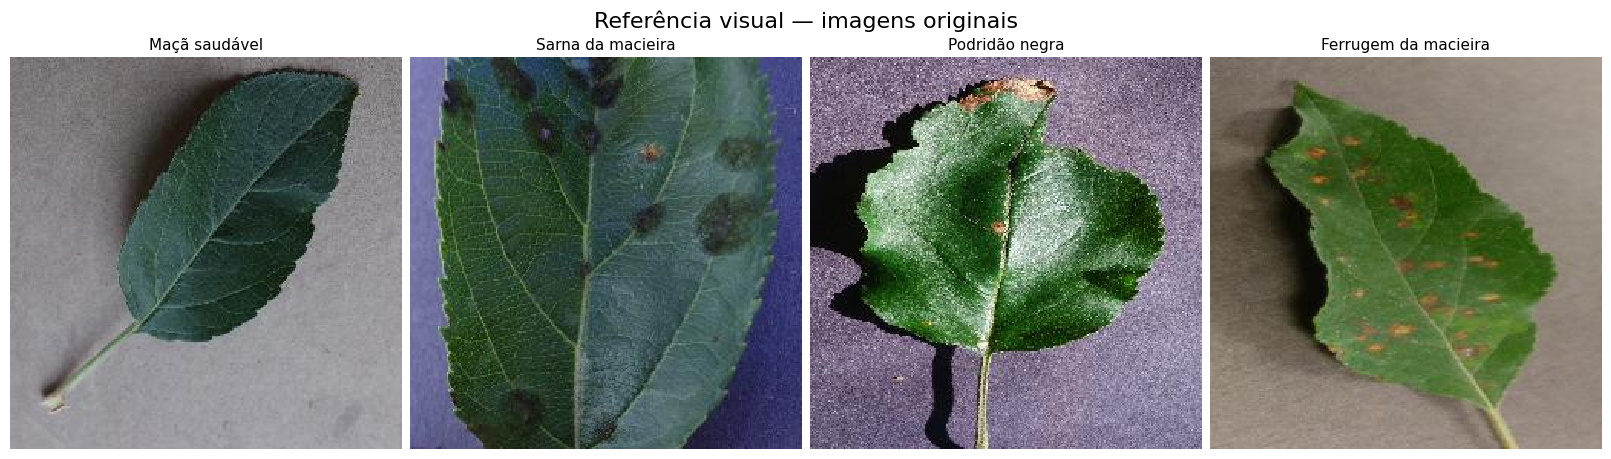

In [11]:
mostrar_amostras()


## Filtro 1 — Mediana


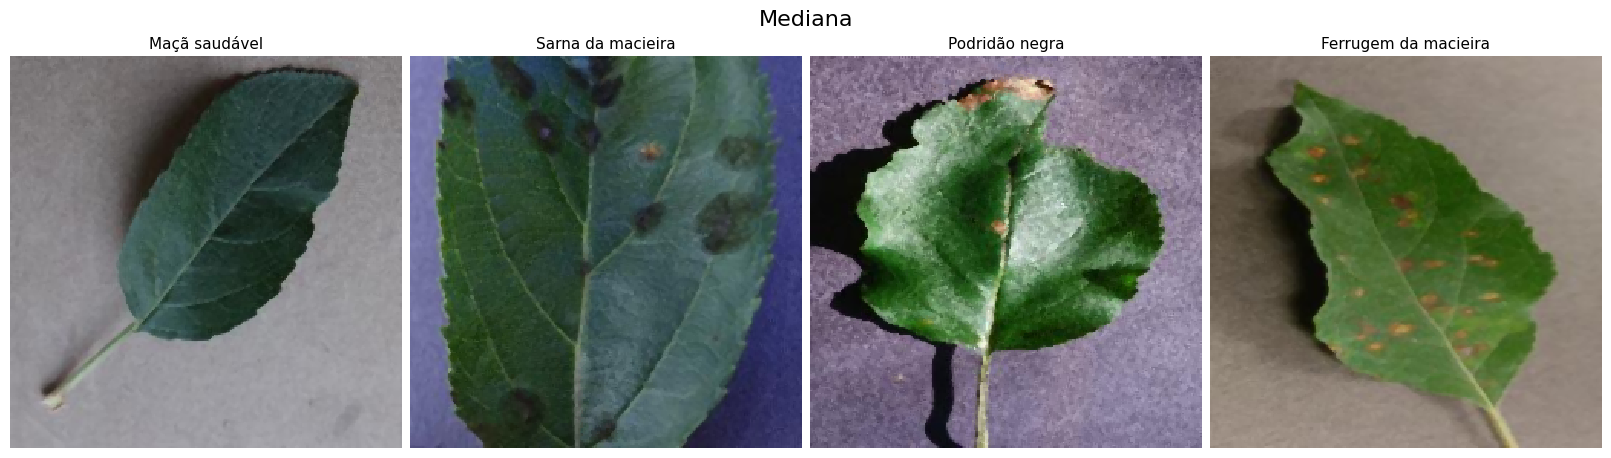

In [12]:
mostrar_filtro("median")


## Filtro 2 — Bilateral


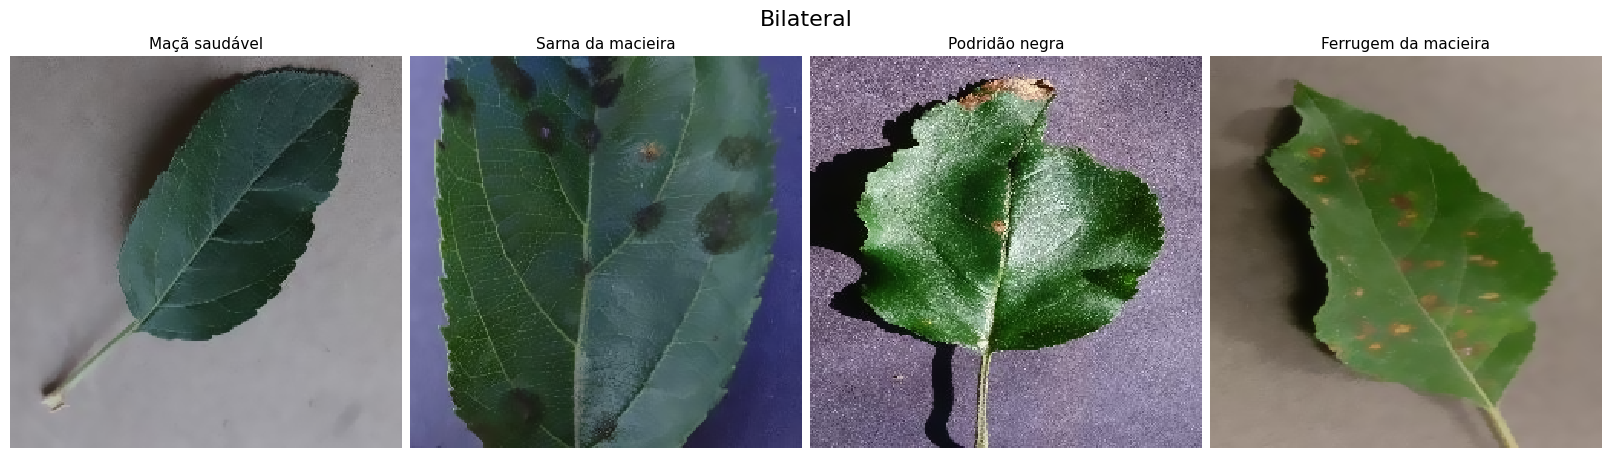

In [13]:
mostrar_filtro("bilateral")


## Filtro 5 — Gaussiano


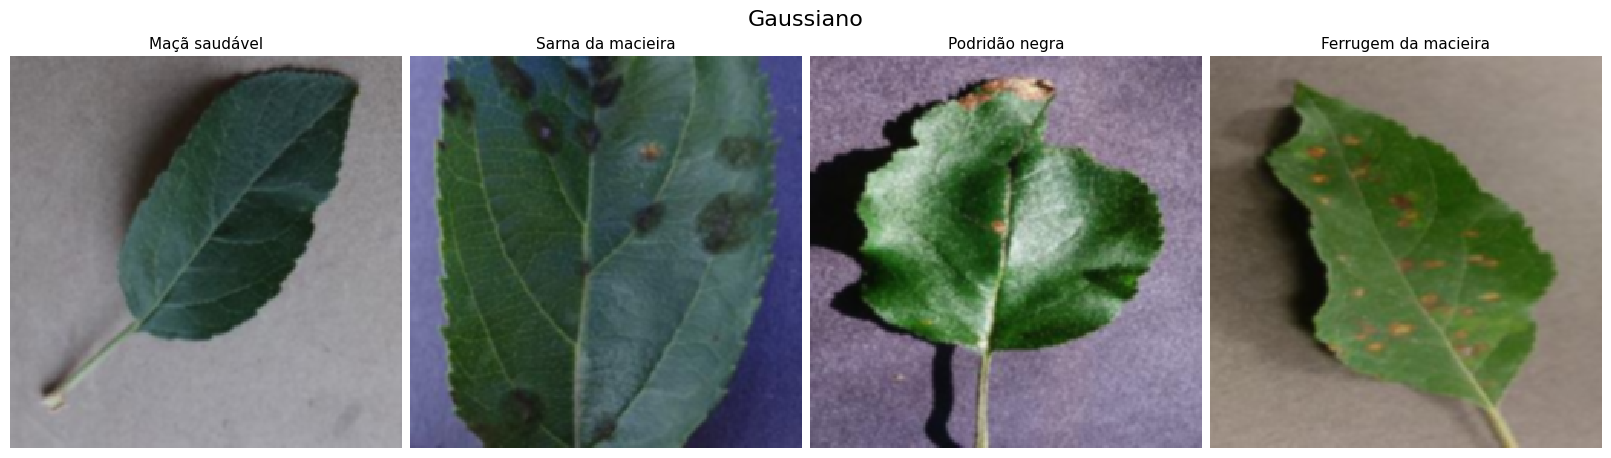

In [14]:
mostrar_filtro("gaussian")


## Escolha para a próxima etapa

A escolha numérica e a escolha visual são registradas separadamente.
A configuração inicial mostra o vencedor numérico como seleção provisória.
O bloco de configuração no início permite registrar a escolha visual, sua justificativa
e a decisão final, sem alterar as células de apresentação.


**Melhor pelas métricas:** Bilateral (sigma 10, PSNR médio 33.471 dB, SSIM 0.8809).

**Escolha visual:** ainda não informada.

**Filtro para a próxima etapa:** Bilateral. Seleção provisória baseada no maior PSNR médio do tuning. A decisão visual ainda deve ser considerada para o pipeline.

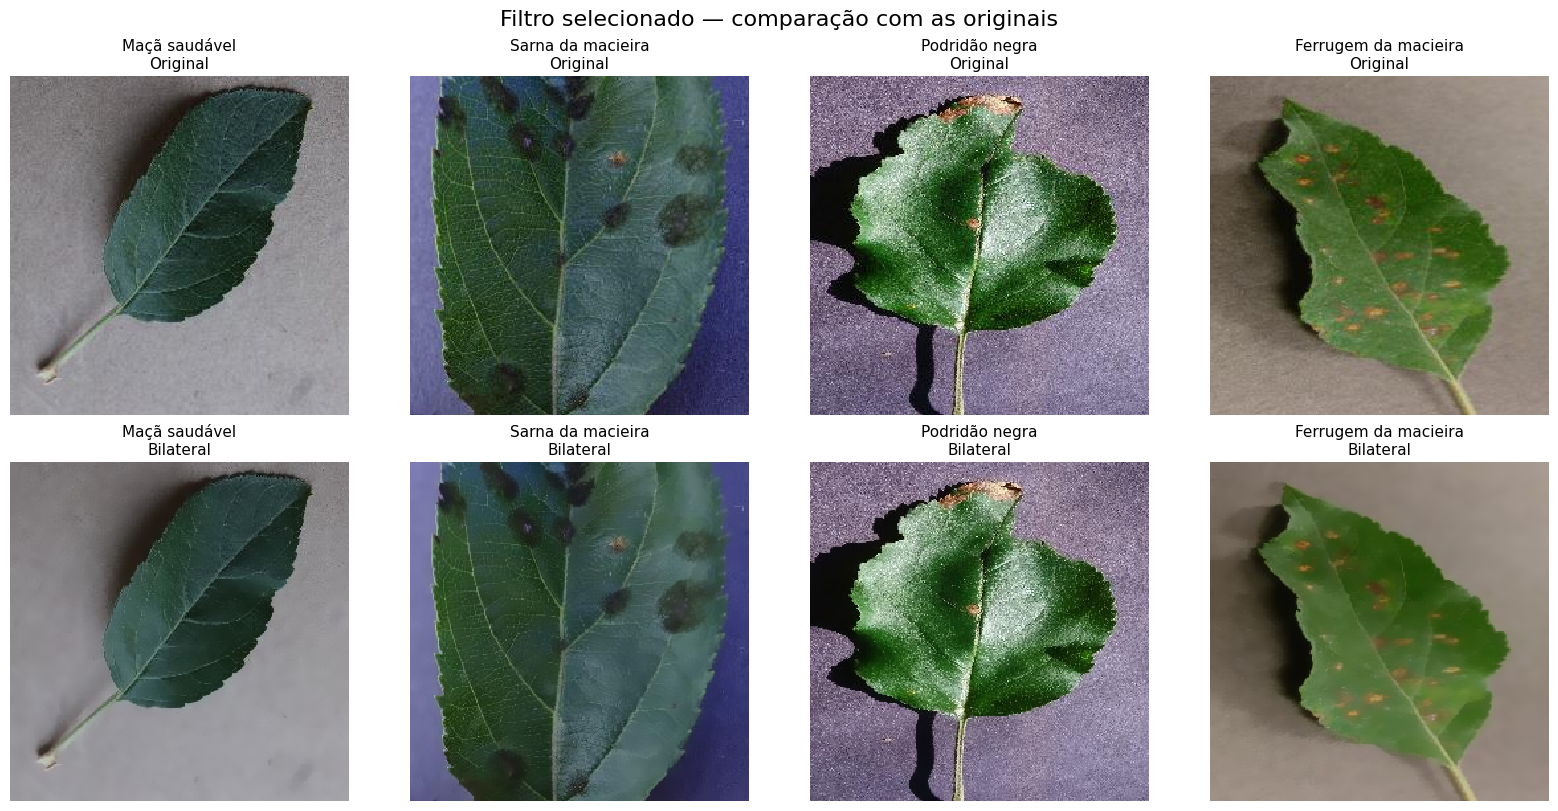

In [15]:
mostrar_escolha()


## Comparação histórica opcional

NLM e BM3D não são executados por padrão. O snapshot de tuning permanece íntegro.


In [16]:
if MOSTRAR_HISTORICOS:
    mostrar_filtro("nlm")
    mostrar_filtro("bm3d")


## Após o denoising: métodos de bordas

Sobel e Canny recebem a mesma imagem filtrada escolhida. Esta etapa mostra apenas
os resultados dos detectores, sem segmentação e sem testes de estabilidade.


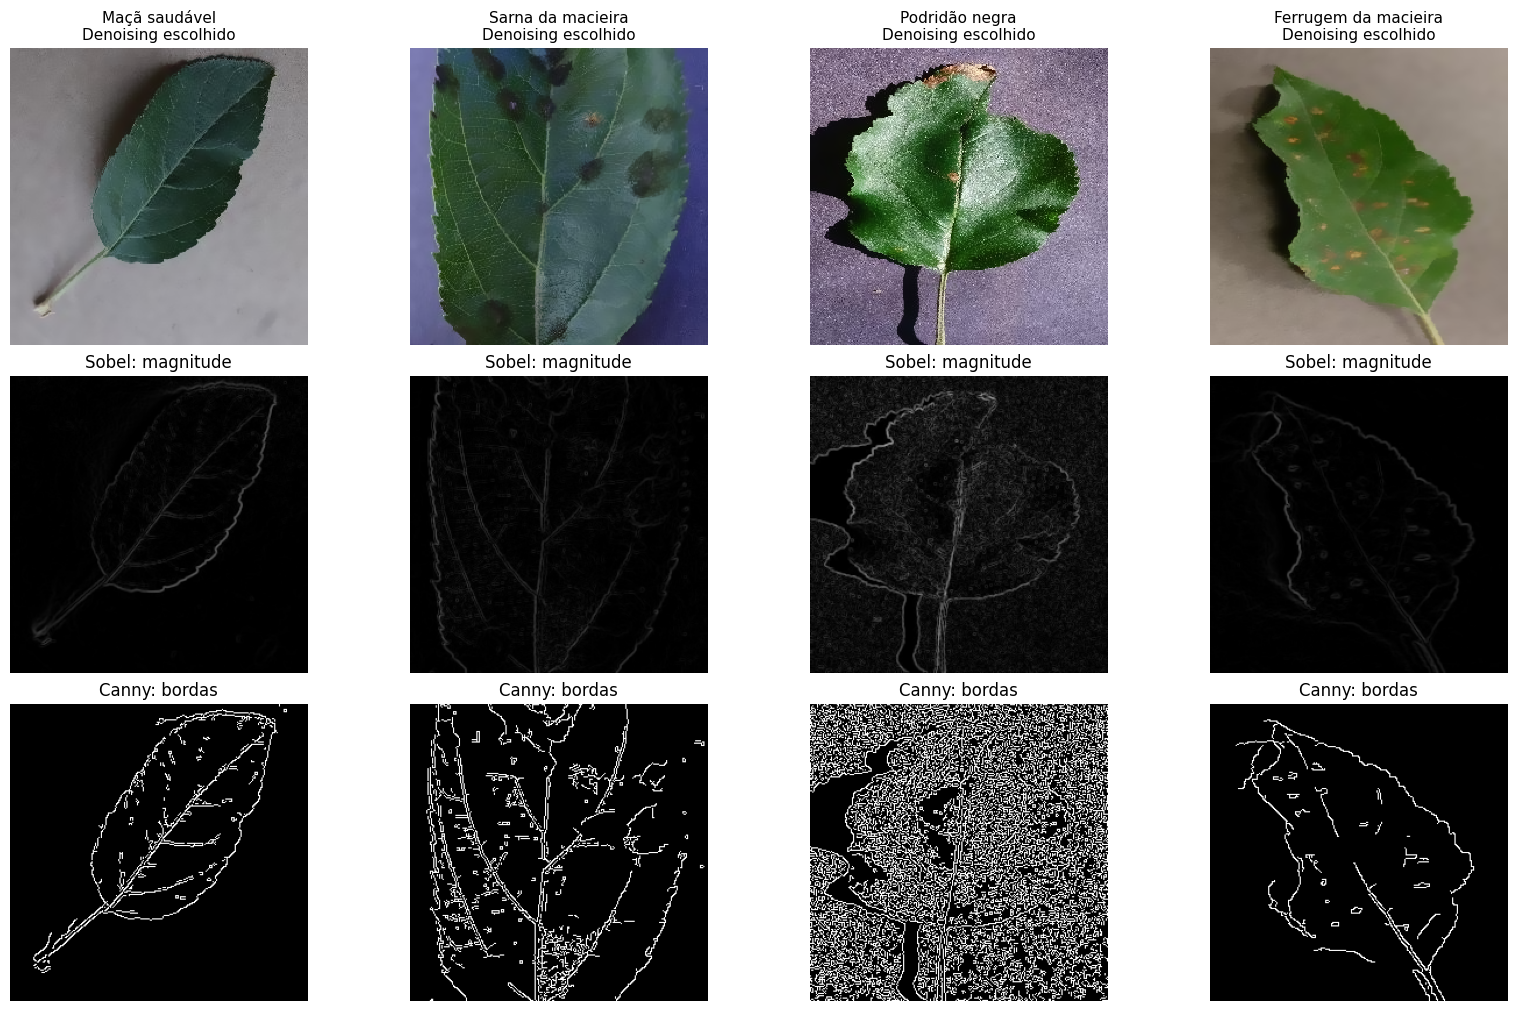

In [17]:
IMAGENS_CINZA = {c: grayscale(im) for c, im in IMAGENS_PRE_PROCESSADAS.items()}
MAPAS_SOBEL = {c: sobel(im) for c, im in IMAGENS_CINZA.items()}
MAPAS_CANNY = {c: canny(im, *LIMIARES_CANNY) for c, im in IMAGENS_CINZA.items()}
mostrar_bordas(IMAGENS_PRE_PROCESSADAS, MAPAS_SOBEL, MAPAS_CANNY)


## Depois das bordas: uma aplicação de GLCM

Aplicamos GLCM somente às quatro ROIs da imagem denoised escolhida, sem comparar
outros métodos de textura ou acrescentar segmentação. Os retângulos mostram a região medida.
Não há escolha automática de lesão, classificação ou estimativa de gravidade.

Esta célula gera somente `outputs/glcm.csv` e `outputs/glcm_summary.csv`.
As figuras e demais tabelas permanecem neste notebook, sem gerar cópias `.ipynb`.


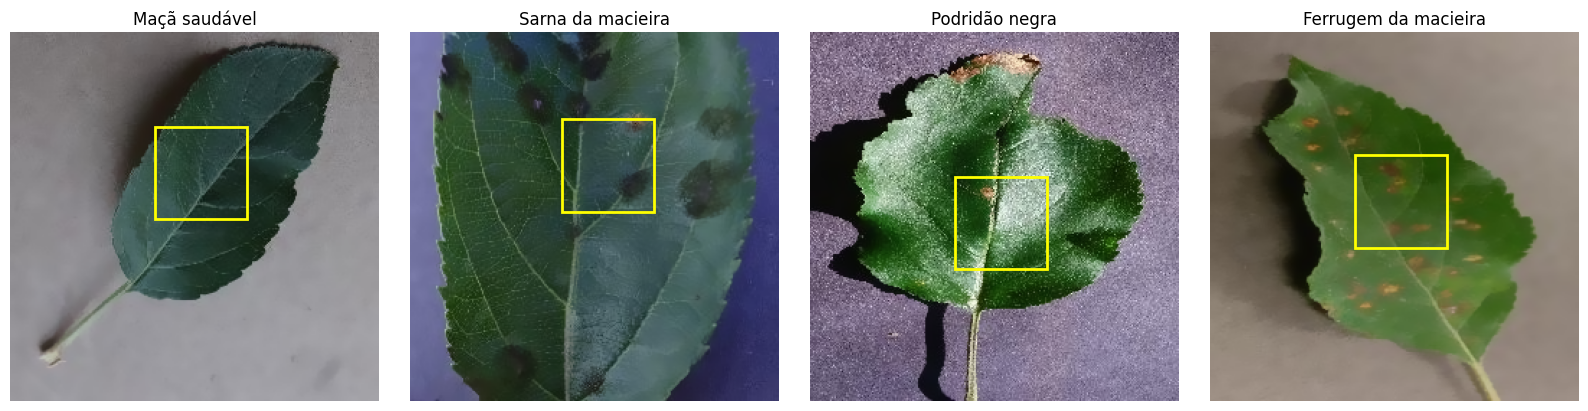

,distancia,angulo_graus,classe,contrast,dissimilarity,homogeneity,energy,ASM,correlation
0,1,0.0,Apple___healthy,1.888145,0.746776,0.716352,0.240232,0.057711,0.777009
1,1,45.0,Apple___healthy,2.753338,0.903502,0.681024,0.229111,0.052492,0.673956
2,1,90.0,Apple___healthy,1.676091,0.708829,0.723832,0.240486,0.057833,0.803703
3,1,135.0,Apple___healthy,1.818846,0.805996,0.683015,0.226851,0.051461,0.784531
4,2,0.0,Apple___healthy,2.915323,0.949093,0.665283,0.224633,0.050460,0.651911
5,2,45.0,Apple___healthy,2.753338,0.903502,0.681024,0.229111,0.052492,0.673956
6,2,90.0,Apple___healthy,3.035030,0.985131,0.657272,0.221226,0.048941,0.643554
7,2,135.0,Apple___healthy,1.818846,0.805996,0.683015,0.226851,0.051461,0.784531
8,4,0.0,Apple___healthy,3.763802,1.121615,0.625271,0.215340,0.046371,0.540046
9,4,45.0,Apple___healthy,4.507390,1.269551,0.597718,0.208266,0.043375,0.451696


,contrast,dissimilarity,homogeneity,energy,ASM,correlation
classe,,,,,,
Apple___Apple_scab,3.0042,1.0032,0.6471,0.2450,0.0602,0.6416
Apple___Black_rot,29.7860,3.7955,0.2986,0.0761,0.0058,0.7531
Apple___Cedar_apple_rust,0.5107,0.3568,0.8367,0.2862,0.0827,0.9188
Apple___healthy,2.8014,0.9490,0.6632,0.2240,0.0503,0.6653


In [18]:
show_rois(IMAGENS_PRE_PROCESSADAS, ROIS, CLASSES)
TABELA_GLCM = calcular_glcm_amostras(IMAGENS_PRE_PROCESSADAS, ROIS)
RESUMO_GLCM = TABELA_GLCM.groupby("classe").mean(numeric_only=True).drop(
    columns=["distancia", "angulo_graus"])
display(TABELA_GLCM)
display(RESUMO_GLCM.round(4))

# Somente resultados produzidos por esta execucao; figuras ficam no notebook.
PASTA_SAIDAS.mkdir(exist_ok=True)
TABELA_GLCM.to_csv(PASTA_SAIDAS / "glcm.csv", index=False)
RESUMO_GLCM.to_csv(PASTA_SAIDAS / "glcm_summary.csv")
